# Darkom data understanding — before cleaning

`data/raw/darkom-annonces_raw.csv`

## 1. Import libraries

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 50)

## 2. Load the raw CSV file

In [3]:
from pathlib import Path
import pandas as pd

# The notebook is inside:
# darkom-real-estate-dwh/scripts/clean/
# So we go two levels up to reach the project root.

PROJECT_ROOT = Path.cwd().parents[1]

RAW_FILE = PROJECT_ROOT / "data" / "raw" / "darkom-annonces_raw.csv"

print("Current notebook folder:", Path.cwd())
print("Project root:", PROJECT_ROOT)
print("Raw file:", RAW_FILE)

df = pd.read_csv(RAW_FILE, encoding="utf-8-sig")

print("Data loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Current notebook folder: c:\Users\chaima\Desktop\Data Analysis\darkom-real-estate-dwh\scripts\clean
Project root: c:\Users\chaima\Desktop\Data Analysis\darkom-real-estate-dwh
Raw file: c:\Users\chaima\Desktop\Data Analysis\darkom-real-estate-dwh\data\raw\darkom-annonces_raw.csv
Data loaded successfully.
Rows: 1508
Columns: 13


## 3. First look at the data

In [4]:
df.head(10)

,annonce_id,date_publication,titre,ville,quartier,type_bien,transaction,prix,surface,nb_chambres,nb_salles_bain,etage,annee_construction
0,ANO000343,2023-05-05,Terrain moderne Meknès,Meknès,Hamria,Terrain,Vente,811401.04,314.40,0.0,NaN,0.0,2014.0
1,ANO001296,2023-08-20,Terrain moderne Kenitra,Kenitra,Centre,Terrain,Location,3843.55,36.46,0.0,0.0,NaN,2008.0
2,ANO001212,2023-06-20,Appartement moderne Oujda,Oujda,Hay Qods,Appartement,Location,9190.70,95.54,2.0,2.0,NaN,2012.0
3,ANO001000,2024-01-21,Appartement à vente - Tanger,Tanger,NaN,Appartement,Vente,30000.00,93.35,1.0,1.0,3.0,2008.0
4,ANO001123,2024-03-19,Beau Villa Rabat,Rabat,Souissi,Villa,Location,20844.72,264.22,3.0,1.0,0.0,2006.0
5,ANO000927,2024-03-19,Appartement 96m² Talborjt,Agadir,Talborjt,Appartement,Vente,542588.30,96.99,3.0,1.0,4.0,2016.0
6,ANO000511,2023-06-12,Bureau à vente - Tanger,TANGER,NaN,Bureau,Vente,1256354.50,49.26,0.0,0.0,NaN,2012.0
7,ANO000608,2023-08-17,Appartement moderne Rabat,Rabat,Agdal,Appartement,Vente,2030740.75,79.38,1.0,1.0,1.0,NaN
8,ANO000153,2024-10-16,Appartement moderne Fès,Fès,Zouagha,Appartement,Vente,537156.36,59.12,1.0,1.0,8.0,1991.0
9,ANO000720,2024-09-12,Beau Appartement Agadir,Agadir,Talborjt,Appartement,Vente,511874.19,117.04,2.0,2.0,1.0,2014.0


In [5]:
df.tail(5)

,annonce_id,date_publication,titre,ville,quartier,type_bien,transaction,prix,surface,nb_chambres,nb_salles_bain,etage,annee_construction
1503,ANO000592,2024-10-22,Appartement moderne Agadir,Agadir,Hay Mohammadi,Appartement,Vente,573352.89,66.44,3.0,1.0,1.0,1999.0
1504,ANO001157,2024-01-05,Appartement à location - Marrakech,Marrakech,Hivernage,Appartement,Location,1981.82,79.53,4.0,3.0,3.0,2009.0
1505,ANO000333,2023-08-30,Beau Bureau Agadir,Agadir,Hay Mohammadi,Bureau,Vente,1919074.61,145.63,0.0,0.0,0.0,2005.0
1506,ANO001089,2024-06-05,Villa 405m² Ain Diab,Casablanca,Ain Diab,Villa,Location,10130.83,405.30,5.0,3.0,NaN,1986.0
1507,ANO001290,2024-02-23,Beau Appartement Fès,Fès,Medina,Appartement,Vente,748434.07,88.50,3.0,2.0,1.0,2014.0


In [6]:
# Random sample helps you see different examples, not only the first rows.
df.sample(10, random_state=42)

,annonce_id,date_publication,titre,ville,quartier,type_bien,transaction,prix,surface,nb_chambres,nb_salles_bain,etage,annee_construction
578,ANO000635,2024-06-16,Beau Bureau Rabat,Rabat,Hay Riad,Bureau,Vente,1669249.86,134.79,0.0,0.0,3.0,NaN
1146,ANO001127,2024-06-10,Beau Appartement Agadir,agadir,Hay Mohammadi,Appartement,Location,2442.86,66.79,3.0,2.0,4.0,2024.0
382,ANO000999,2023-10-08,Bureau à vente - Meknès,Meknès,NaN,Bureau,Vente,819232.62,123.10,0.0,NaN,NaN,2012.0
583,ANO001311,2023-09-09,Villa 372m² Kenitra,Kenitra,NaN,Villa,Vente,2535765.59,372.24,5.0,3.0,0.0,2017.0
966,ANO000622,2023-06-14,Beau Villa Tanger,Tanger,Iberia,Villa,Location,13508.81,354.35,3.0,1.0,0.0,1996.0
1173,ANO000630,2024-05-21,Bureau 101m² Agdal,Rabat,Agdal,Bureau,Vente,1369624.42,101.05,0.0,0.0,7.0,NaN
175,ANO001244,2023-06-27,Beau Terrain Tanger,Tanger,Centre Ville,Terrain,Vente,105156.84,402.96,0.0,0.0,0.0,2003.0
1084,ANO000313,2024-09-03,Appartement 102m² Hay Essalam,Kenitra,Hay Essalam,Appartement,Vente,1591506.87,102.71,3.0,NaN,0.0,2011.0
705,ANO001426,2024-02-19,Villa 202m² Hivernage,Marrakech,Hivernage,Villa,Vente,2149359.64,202.12,3.0,NaN,NaN,2002.0
1102,ANO000109,2023-02-04,Appartement moderne Rabat,Rabat,NaN,NaN,Vente,429277.91,54.65,2.0,NaN,1.0,2017.0


## 4. Column names and raw data types

In [7]:
df.columns.tolist()

['annonce_id',
 'date_publication',
 'titre',
 'ville',
 'quartier',
 'type_bien',
 'transaction',
 'prix',
 'surface',
 'nb_chambres',
 'nb_salles_bain',
 'etage',
 'annee_construction']

In [8]:
pd.DataFrame({
    "column": df.columns,
    "raw_dtype": [df[col].dtype for col in df.columns]
})

,column,raw_dtype
0,annonce_id,object
1,date_publication,object
2,titre,object
3,ville,object
4,quartier,object
5,type_bien,object
6,transaction,object
7,prix,float64
8,surface,float64
9,nb_chambres,float64


## 5. Expected structure check

In [9]:
expected_columns = [
    "annonce_id",
    "date_publication",
    "titre",
    "ville",
    "quartier",
    "type_bien",
    "transaction",
    "prix",
    "surface",
    "nb_chambres",
    "nb_salles_bain",
    "etage",
    "annee_construction",
]

structure_check = pd.DataFrame({
    "expected_column": expected_columns,
    "exists_in_data": [col in df.columns for col in expected_columns]
})

missing_expected_columns = [col for col in expected_columns if col not in df.columns]
extra_columns = [col for col in df.columns if col not in expected_columns]

display(structure_check)

print("Missing expected columns:", missing_expected_columns)
print("Extra columns:", extra_columns)

,expected_column,exists_in_data
0,annonce_id,True
1,date_publication,True
2,titre,True
3,ville,True
4,quartier,True
5,type_bien,True
6,transaction,True
7,prix,True
8,surface,True
9,nb_chambres,True


Missing expected columns: []
Extra columns: []


## 6. Missing values

This section detects both real missing values and text-like missing values such as empty strings, `nan`, `none`, `null`, `n/a`.

In [10]:
def is_missing_like(series):
    text_series = series.astype("string").str.strip().str.lower()
    return (
        series.isna()
        | text_series.isin(["", "nan", "none", "null", "na", "n/a", "?"])
    )

missing_summary = []

for col in df.columns:
    missing_mask = is_missing_like(df[col])
    missing_summary.append({
        "column": col,
        "missing_count": int(missing_mask.sum()),
        "missing_percent": round(missing_mask.mean() * 100, 2),
        "non_missing_count": int((~missing_mask).sum())
    })

missing_summary = (
    pd.DataFrame(missing_summary)
    .sort_values("missing_percent", ascending=False)
    .reset_index(drop=True)
)

missing_summary

,column,missing_count,missing_percent,non_missing_count
0,quartier,415,27.52,1093
1,etage,232,15.38,1276
2,annee_construction,204,13.53,1304
3,nb_chambres,129,8.55,1379
4,nb_salles_bain,104,6.90,1404
5,date_publication,76,5.04,1432
6,transaction,38,2.52,1470
7,type_bien,38,2.52,1470
8,annonce_id,0,0.00,1508
9,ville,0,0.00,1508


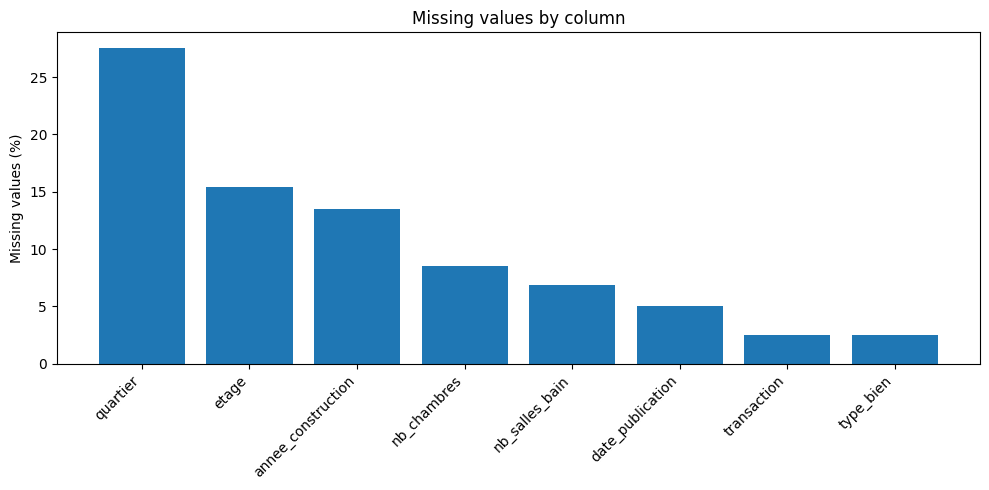

In [11]:
missing_plot = missing_summary[missing_summary["missing_count"] > 0].copy()

if missing_plot.empty:
    print("No missing values detected.")
else:
    plt.figure(figsize=(10, 5))
    plt.bar(missing_plot["column"], missing_plot["missing_percent"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Missing values (%)")
    plt.title("Missing values by column")
    plt.tight_layout()
    plt.show()

## 7. Duplicate analysis

In [12]:
exact_duplicate_rows = df.duplicated().sum()

print("Exact duplicated rows:", exact_duplicate_rows)

if "annonce_id" in df.columns:
    duplicated_annonce_id = df["annonce_id"].duplicated().sum()
    print("Duplicated annonce_id:", duplicated_annonce_id)

    duplicate_ids = df["annonce_id"].value_counts()
    duplicate_ids = duplicate_ids[duplicate_ids > 1]

    display(duplicate_ids.head(20))
else:
    print("Column annonce_id does not exist.")

Exact duplicated rows: 8
Duplicated annonce_id: 8


annonce_id
ANO000248    2
ANO000263    2
ANO000679    2
ANO000868    2
ANO001471    2
ANO000824    2
ANO000762    2
ANO001047    2
Name: count, dtype: int64

In [13]:
if "annonce_id" in df.columns:
    duplicated_rows = df[df["annonce_id"].duplicated(keep=False)].sort_values("annonce_id")
    display(duplicated_rows.head(30))

,annonce_id,date_publication,titre,ville,quartier,type_bien,transaction,prix,surface,nb_chambres,nb_salles_bain,etage,annee_construction
577,ANO000248,2023-05-29,Appartement moderne Tétouan,Tétouan,M'diq,Appartement,Vente,1488169.21,69.38,1.0,1.0,6.0,2010.0
1258,ANO000248,2023-05-29,Appartement moderne Tétouan,Tétouan,M'diq,Appartement,Vente,1488169.21,69.38,1.0,1.0,6.0,2010.0
127,ANO000263,2023-12-02,Terrain moderne Marrakech,Marrakech,Gueliz,Terrain,Location,4200.71,355.10,0.0,NaN,0.0,2009.0
1307,ANO000263,2023-12-02,Terrain moderne Marrakech,Marrakech,Gueliz,Terrain,Location,4200.71,355.10,0.0,NaN,0.0,2009.0
364,ANO000679,2023-10-01,Appartement à vente - Casablanca,Casablanca,Californie,Appartement,Vente,677225.19,153.99,3.0,2.0,4.0,2005.0
599,ANO000679,2023-10-01,Appartement à vente - Casablanca,Casablanca,Californie,Appartement,Vente,677225.19,153.99,3.0,2.0,4.0,2005.0
988,ANO000762,2023-01-24,Beau Appartement Rabat,Rabat,Hay Riad,Appartement,Vente,432260.14,73.39,2.0,1.0,4.0,2006.0
1058,ANO000762,2023-01-24,Beau Appartement Rabat,Rabat,Hay Riad,Appartement,Vente,432260.14,73.39,2.0,1.0,4.0,2006.0
320,ANO000824,2024-06-27,Terrain 428m² Hay Mohammadi,Agadir,Hay Mohammadi,Terrain,Vente,737205.85,428.76,0.0,0.0,0.0,2024.0
585,ANO000824,2024-06-27,Terrain 428m² Hay Mohammadi,Agadir,Hay Mohammadi,Terrain,Vente,737205.85,428.76,0.0,0.0,0.0,2024.0


## 8. Categorical variables

In [14]:
categorical_columns = ["ville", "quartier", "type_bien", "transaction"]

for col in categorical_columns:
    if col in df.columns:
        print("\n" + "=" * 80)
        print("Column:", col)
        print("Unique values:", df[col].nunique(dropna=True))
        print("Missing values:", int(is_missing_like(df[col]).sum()))
        display(df[col].where(~is_missing_like(df[col]), "Missing").value_counts(dropna=False).head(20))


Column: ville
Unique values: 31
Missing values: 0


ville
Marrakech     148
Tétouan       145
Casablanca    142
Meknès        142
Kenitra       137
Tanger        135
Rabat         133
Agadir        131
Oujda         130
Fès           120
tétouan        13
MARRAKECH      12
TANGER         11
TÉTOUAN         9
oujda           9
rabat           8
MEKNÈS          8
OUJDA           7
RABAT           7
casablanca      7
Name: count, dtype: int64


Column: quartier
Unique values: 27
Missing values: 415


quartier
Missing           415
Centre            168
Ville Nouvelle     84
Medina             74
M'diq              59
Hay Qods           58
Hamria             51
Hay Mohammadi      49
Hay Essalam        45
Talborjt           44
Iberia             35
Centre Ville       34
Malabata           32
Targa              31
Hay Riad           31
Hivernage          28
Zouagha            28
Gueliz             28
Ocean              27
Hassan             27
Name: count, dtype: int64


Column: type_bien
Unique values: 5
Missing values: 38


type_bien
Appartement    744
Villa          367
Terrain        150
Bureau         141
Duplex          68
Missing         38
Name: count, dtype: int64


Column: transaction
Unique values: 2
Missing values: 38


transaction
Vente       1048
Location     422
Missing       38
Name: count, dtype: int64

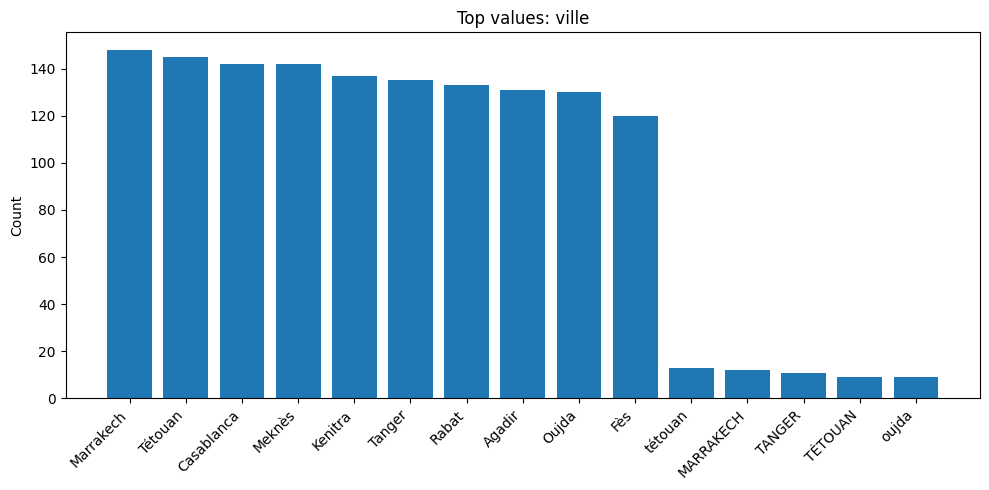

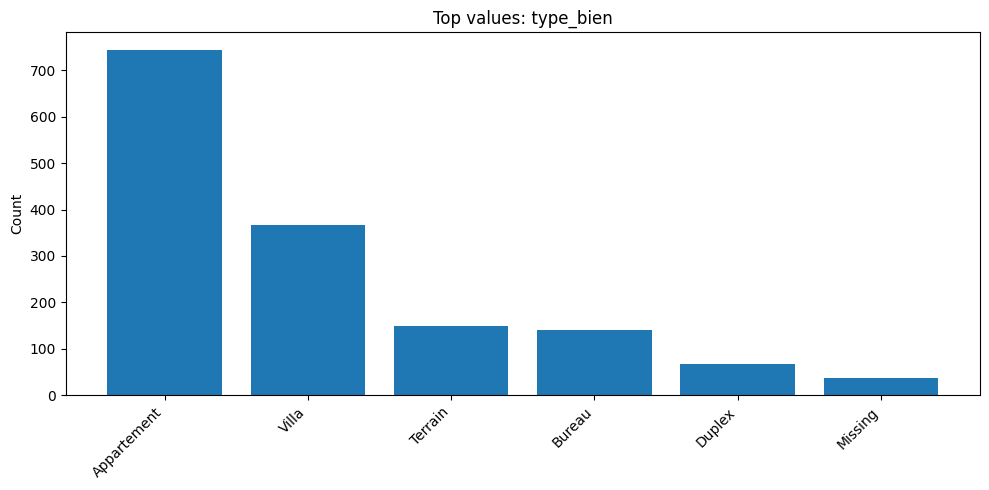

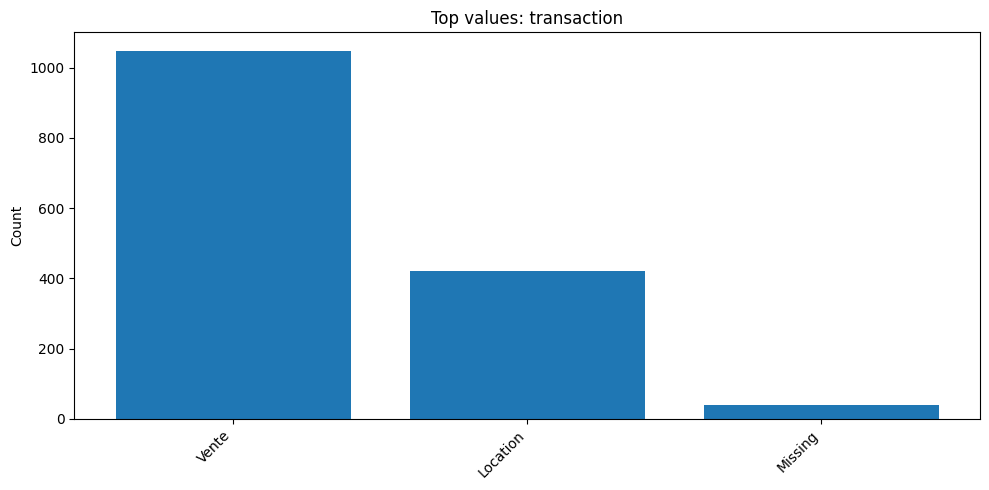

In [15]:
for col in ["ville", "type_bien", "transaction"]:
    if col in df.columns:
        values = df[col].where(~is_missing_like(df[col]), "Missing").value_counts().head(15)

        plt.figure(figsize=(10, 5))
        plt.bar(values.index.astype(str), values.values)
        plt.xticks(rotation=45, ha="right")
        plt.ylabel("Count")
        plt.title(f"Top values: {col}")
        plt.tight_layout()
        plt.show()

## 9. Convert numeric columns for analysis only

The raw CSV may store numbers as text.  
Here we convert them only inside the notebook to understand the data.

In [16]:
numeric_columns = [
    "prix",
    "surface",
    "nb_chambres",
    "nb_salles_bain",
    "etage",
    "annee_construction",
]

def parse_numeric_series(series):
    cleaned = (
        series.astype("string")
        .str.replace("\u00a0", "", regex=False)
        .str.replace(" ", "", regex=False)
        .str.replace(",", ".", regex=False)
        .str.replace("MAD", "", regex=False)
        .str.replace("mad", "", regex=False)
        .str.strip()
    )
    return pd.to_numeric(cleaned, errors="coerce")

numeric_df = pd.DataFrame()

numeric_quality = []

for col in numeric_columns:
    if col in df.columns:
        original_missing = is_missing_like(df[col])
        numeric_series = parse_numeric_series(df[col])
        invalid_numeric = numeric_series.isna() & (~original_missing)

        numeric_df[col] = numeric_series

        numeric_quality.append({
            "column": col,
            "raw_missing_count": int(original_missing.sum()),
            "invalid_numeric_count": int(invalid_numeric.sum()),
            "valid_numeric_count": int(numeric_series.notna().sum()),
            "zero_count": int((numeric_series == 0).sum()),
            "negative_count": int((numeric_series < 0).sum())
        })

numeric_quality = pd.DataFrame(numeric_quality)
numeric_quality

,column,raw_missing_count,invalid_numeric_count,valid_numeric_count,zero_count,negative_count
0,prix,0,0,1508,0,0
1,surface,0,0,1508,0,0
2,nb_chambres,129,0,1379,266,0
3,nb_salles_bain,104,0,1404,276,0
4,etage,232,0,1276,614,0
5,annee_construction,204,0,1304,0,0


## 10. Numeric descriptive statistics

In [17]:
numeric_stats = numeric_df.describe().T
numeric_stats["median"] = numeric_df.median()
numeric_stats = numeric_stats[
    ["count", "mean", "median", "std", "min", "25%", "50%", "75%", "max"]
]
numeric_stats.round(2)

,count,mean,median,std,min,25%,50%,75%,max
prix,1508.0,1725598.92,605583.47,6235344.26,120.0,11549.16,605583.47,1819006.55,80000000.0
surface,1508.0,175.81,109.8,264.17,8.0,79.88,109.8,218.2,3000.0
nb_chambres,1379.0,2.65,3.0,2.65,0.0,1.0,3.0,4.0,25.0
nb_salles_bain,1404.0,1.54,1.0,1.36,0.0,1.0,1.0,2.0,13.0
etage,1276.0,1.93,1.0,2.45,0.0,0.0,1.0,3.0,10.0
annee_construction,1304.0,2007.05,2008.0,10.73,1961.0,2001.0,2008.0,2014.0,2024.0


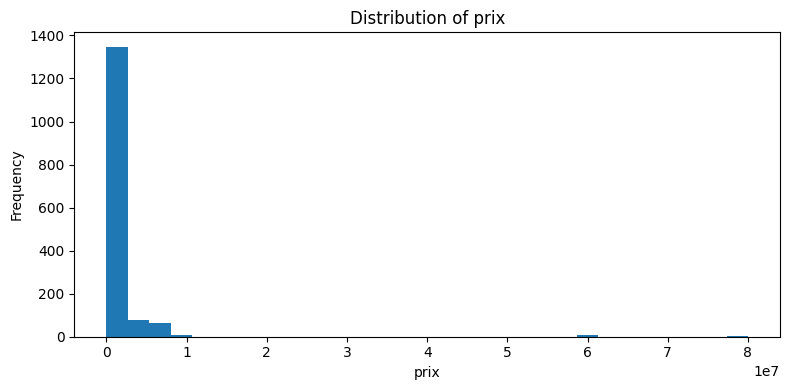

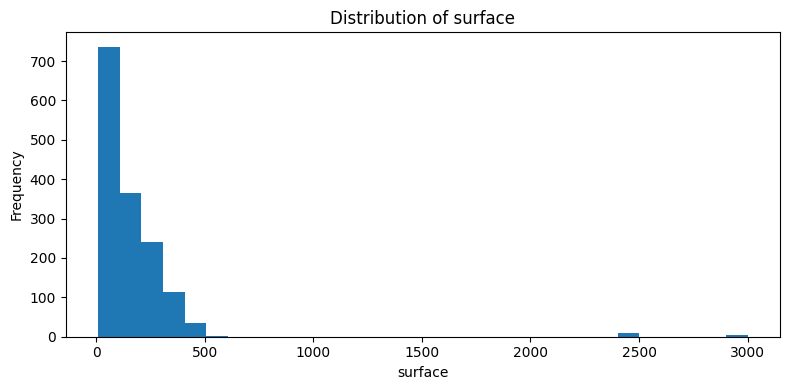

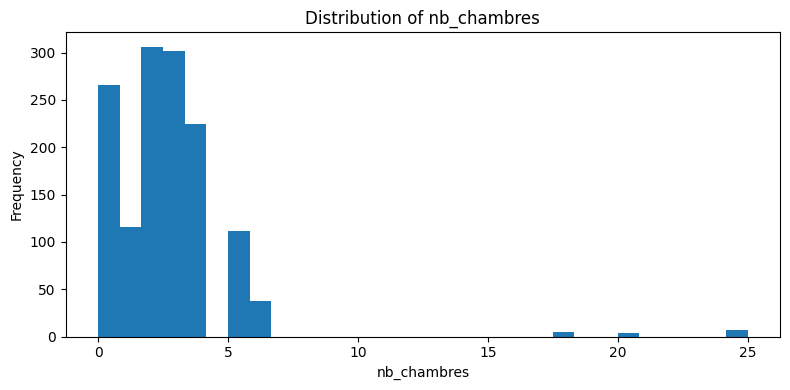

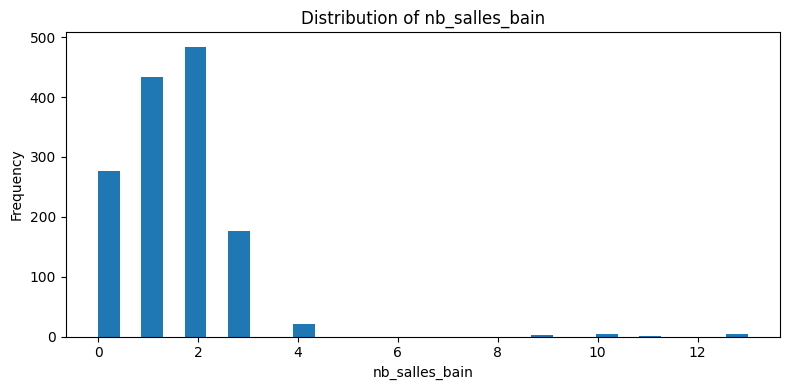

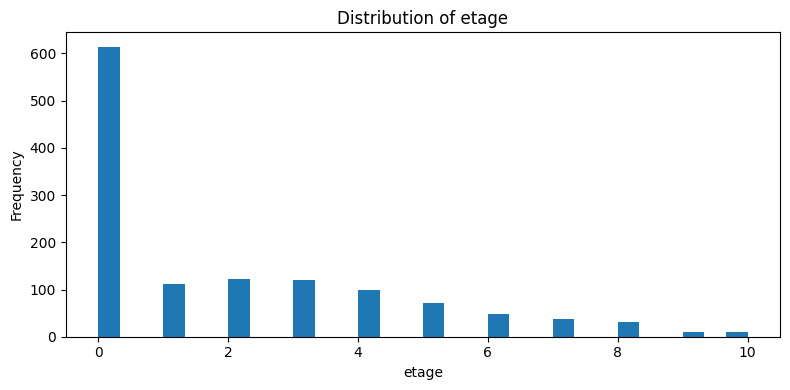

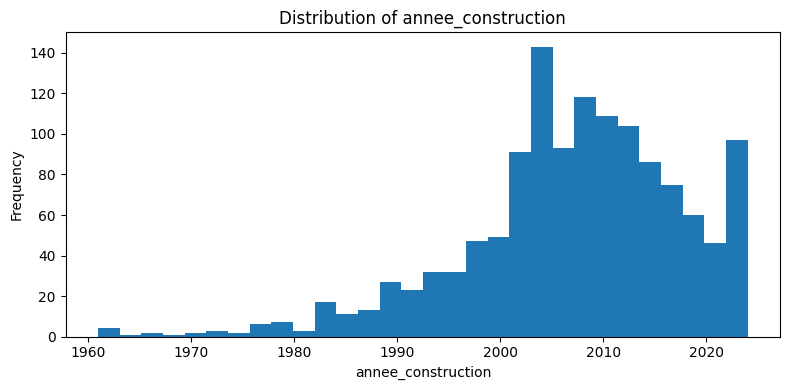

In [18]:
for col in numeric_df.columns:
    values = numeric_df[col].dropna()

    if values.empty:
        continue

    plt.figure(figsize=(8, 4))
    plt.hist(values, bins=30)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

## 11. Date quality

In [19]:
if "date_publication" in df.columns:
    raw_dates_missing = is_missing_like(df["date_publication"])
    parsed_dates = pd.to_datetime(df["date_publication"], errors="coerce")
    invalid_dates = parsed_dates.isna() & (~raw_dates_missing)

    date_quality = pd.DataFrame([{
        "missing_dates": int(raw_dates_missing.sum()),
        "invalid_dates": int(invalid_dates.sum()),
        "valid_dates": int(parsed_dates.notna().sum()),
        "min_date": parsed_dates.min(),
        "max_date": parsed_dates.max()
    }])

    display(date_quality)
else:
    print("date_publication column not found.")

,missing_dates,invalid_dates,valid_dates,min_date,max_date
0,76,0,1432,2023-01-01,2024-12-30


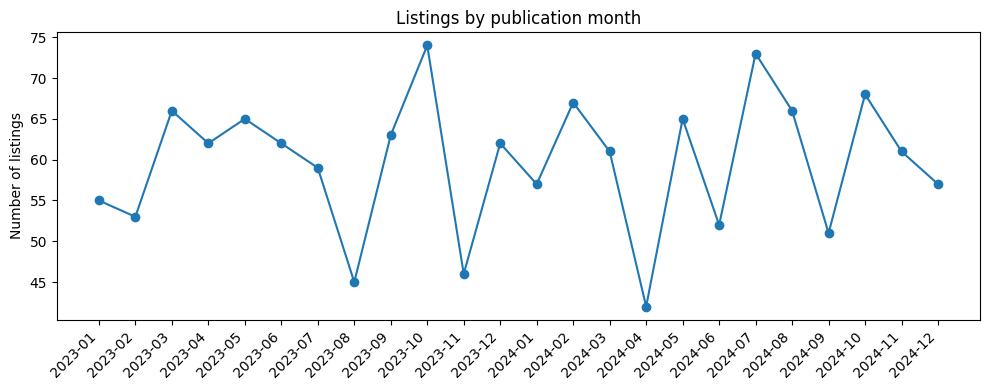

In [20]:
if "date_publication" in df.columns:
    date_counts = parsed_dates.dt.to_period("M").value_counts().sort_index()

    if date_counts.empty:
        print("No valid dates to plot.")
    else:
        plt.figure(figsize=(10, 4))
        plt.plot(date_counts.index.astype(str), date_counts.values, marker="o")
        plt.xticks(rotation=45, ha="right")
        plt.ylabel("Number of listings")
        plt.title("Listings by publication month")
        plt.tight_layout()
        plt.show()

## 12. Business rule anomalies

In [21]:
business_checks = []

def add_business_rule(rule_name, condition):
    business_checks.append({
        "rule": rule_name,
        "count": int(condition.sum()),
        "percent": round(condition.mean() * 100, 2)
    })

if "prix" in numeric_df.columns:
    add_business_rule("prix <= 0", numeric_df["prix"] <= 0)

if "surface" in numeric_df.columns:
    add_business_rule("surface <= 0", numeric_df["surface"] <= 0)
    add_business_rule("surface < 10", numeric_df["surface"] < 10)
    add_business_rule("surface > 1000", numeric_df["surface"] > 1000)

if "nb_chambres" in numeric_df.columns:
    add_business_rule("nb_chambres < 0", numeric_df["nb_chambres"] < 0)
    add_business_rule("nb_chambres > 10", numeric_df["nb_chambres"] > 10)

if "nb_salles_bain" in numeric_df.columns:
    add_business_rule("nb_salles_bain < 0", numeric_df["nb_salles_bain"] < 0)
    add_business_rule("nb_salles_bain > 10", numeric_df["nb_salles_bain"] > 10)

if "etage" in numeric_df.columns:
    add_business_rule("etage < 0", numeric_df["etage"] < 0)
    add_business_rule("etage > 50", numeric_df["etage"] > 50)

if "annee_construction" in numeric_df.columns:
    current_year = pd.Timestamp.today().year
    add_business_rule(
        f"annee_construction < 1900 or > {current_year}",
        (numeric_df["annee_construction"] < 1900) | (numeric_df["annee_construction"] > current_year)
    )

business_checks = pd.DataFrame(business_checks)
business_checks

,rule,count,percent
0,prix <= 0,0,0.00
1,surface <= 0,0,0.00
2,surface < 10,4,0.27
3,surface > 1000,14,0.93
4,nb_chambres < 0,0,0.00
5,nb_chambres > 10,16,1.16
6,nb_salles_bain < 0,0,0.00
7,nb_salles_bain > 10,6,0.43
8,etage < 0,0,0.00
9,etage > 50,0,0.00


## 13. Outlier detection with IQR

In [22]:
def detect_iqr_outliers(series):
    values = series.dropna()

    if len(values) < 4:
        return {
            "outlier_count": 0,
            "outlier_percent": 0,
            "lower_bound": None,
            "upper_bound": None
        }

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    if pd.isna(iqr) or iqr == 0:
        return {
            "outlier_count": 0,
            "outlier_percent": 0,
            "lower_bound": None,
            "upper_bound": None
        }

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = (series < lower_bound) | (series > upper_bound)

    return {
        "outlier_count": int(outliers.sum()),
        "outlier_percent": round(outliers.mean() * 100, 2),
        "lower_bound": round(lower_bound, 2),
        "upper_bound": round(upper_bound, 2)
    }

outlier_summary = []

for col in numeric_df.columns:
    result = detect_iqr_outliers(numeric_df[col])
    result["column"] = col
    outlier_summary.append(result)

if "prix" in numeric_df.columns and "surface" in numeric_df.columns:
    prix_m2_temp = numeric_df["prix"] / numeric_df["surface"]
    prix_m2_temp = prix_m2_temp.replace([np.inf, -np.inf], np.nan)
    result = detect_iqr_outliers(prix_m2_temp)
    result["column"] = "prix_m2_temp"
    outlier_summary.append(result)

outlier_summary = pd.DataFrame(outlier_summary)
outlier_summary[["column", "outlier_count", "outlier_percent", "lower_bound", "upper_bound"]]

,column,outlier_count,outlier_percent,lower_bound,upper_bound
0,prix,101,6.70,-2699636.93,4530192.64
1,surface,40,2.65,-127.60,425.69
2,nb_chambres,16,1.16,-3.50,8.50
3,nb_salles_bain,34,2.42,-0.50,3.50
4,etage,51,4.00,-4.50,7.50
5,annee_construction,31,2.38,1981.50,2033.50
6,prix_m2_temp,104,6.90,-17743.84,29867.69


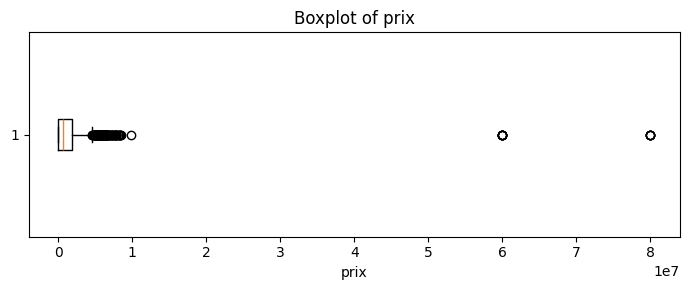

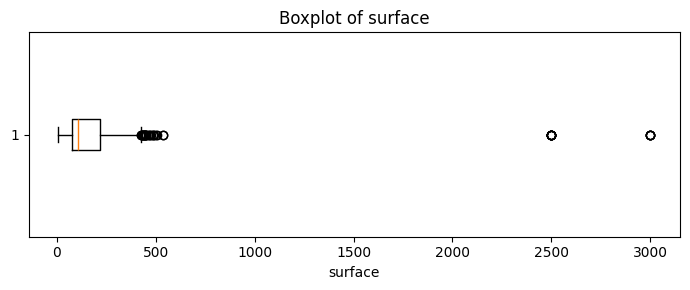

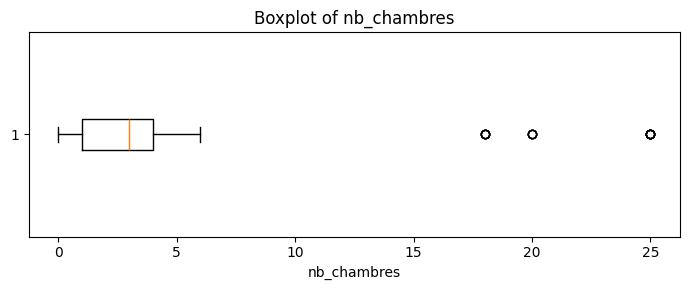

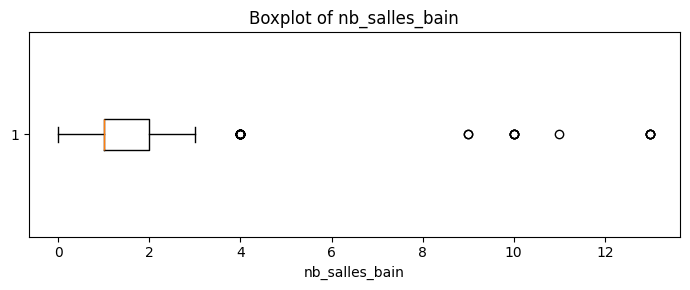

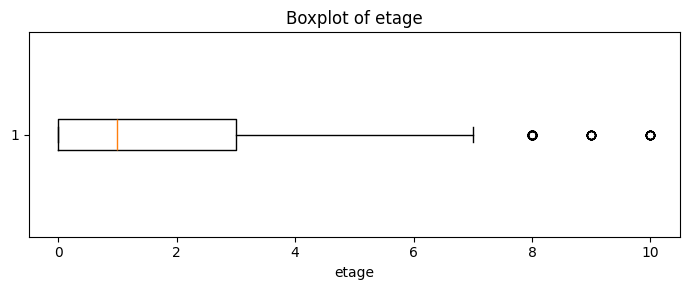

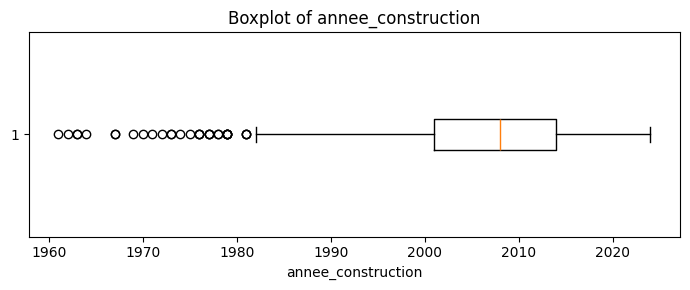

In [23]:
for col in numeric_df.columns:
    values = numeric_df[col].dropna()

    if values.empty:
        continue

    plt.figure(figsize=(7, 3))
    plt.boxplot(values, vert=False)
    plt.xlabel(col)
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

## 14. Price per m² quick exploration

,annonce_id,ville,type_bien,transaction,prix_num,surface_num,prix_m2_temp
0,ANO000343,Meknès,Terrain,Vente,811401.04,314.4,2580.792112
1,ANO001296,Kenitra,Terrain,Location,3843.55,36.46,105.418267
2,ANO001212,Oujda,Appartement,Location,9190.7,95.54,96.197404
3,ANO001000,Tanger,Appartement,Vente,30000.0,93.35,321.371184
4,ANO001123,Rabat,Villa,Location,20844.72,264.22,78.89153
5,ANO000927,Agadir,Appartement,Vente,542588.3,96.99,5594.270543
6,ANO000511,TANGER,Bureau,Vente,1256354.5,49.26,25504.55745
7,ANO000608,Rabat,Appartement,Vente,2030740.75,79.38,25582.523936
8,ANO000153,Fès,Appartement,Vente,537156.36,59.12,9085.865359
9,ANO000720,Agadir,Appartement,Vente,511874.19,117.04,4373.497864


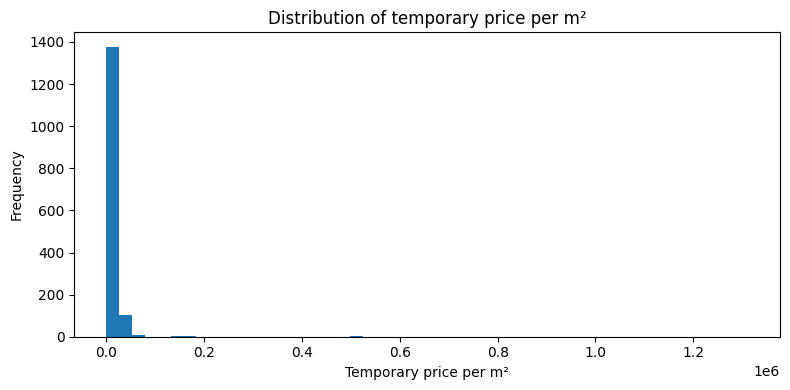

In [24]:
if "prix" in numeric_df.columns and "surface" in numeric_df.columns:
    df_explore = df.copy()
    df_explore["prix_num"] = numeric_df["prix"]
    df_explore["surface_num"] = numeric_df["surface"]
    df_explore["prix_m2_temp"] = df_explore["prix_num"] / df_explore["surface_num"]
    df_explore["prix_m2_temp"] = df_explore["prix_m2_temp"].replace([np.inf, -np.inf], np.nan)

    display(df_explore[["annonce_id", "ville", "type_bien", "transaction", "prix_num", "surface_num", "prix_m2_temp"]].head(20))

    plt.figure(figsize=(8, 4))
    plt.hist(df_explore["prix_m2_temp"].dropna(), bins=50)
    plt.xlabel("Temporary price per m²")
    plt.ylabel("Frequency")
    plt.title("Distribution of temporary price per m²")
    plt.tight_layout()
    plt.show()
else:
    print("prix or surface is missing.")

## 15. Interactive column explorer

In [25]:
try:
    import ipywidgets as widgets
    from IPython.display import display

    column_dropdown = widgets.Dropdown(
        options=df.columns.tolist(),
        description="Column:",
        style={"description_width": "initial"}
    )

    def explore_column(column):
        print("Column:", column)
        print("Raw dtype:", df[column].dtype)
        print("Missing-like values:", int(is_missing_like(df[column]).sum()))
        print("Unique values:", df[column].nunique(dropna=True))
        print("\nTop values:")
        display(df[column].where(~is_missing_like(df[column]), "Missing").value_counts(dropna=False).head(20))
        print("\nSample values:")
        display(df[[column]].sample(10, random_state=1))

    widgets.interact(explore_column, column=column_dropdown)

except ImportError:
    print("ipywidgets is not installed.")
    print("Install it with: python -m pip install ipywidgets")

ipywidgets is not installed.
Install it with: python -m pip install ipywidgets


## 16. Final beginner summary

In [26]:
print("DATA UNDERSTANDING SUMMARY")
print("=" * 60)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Total missing-like values:", int(missing_summary["missing_count"].sum()))

if "annonce_id" in df.columns:
    print("Duplicated annonce_id:", int(df["annonce_id"].duplicated().sum()))

print("\nColumns with missing values:")
display(missing_summary[missing_summary["missing_count"] > 0])

print("\nNumeric quality:")
display(numeric_quality)

print("\nBusiness anomalies:")
display(business_checks)

print("\nOutlier summary:")
display(outlier_summary)

print("\nRecommended next cleaning decisions:")
print("- Remove duplicated annonce_id.")
print("- Convert date_publication to date.")
print("- Convert prix, surface, nb_chambres, nb_salles_bain, etage, and annee_construction to numeric.")
print("- Fill missing quartier with 'Non renseigné'.")
print("- Infer missing type_bien from titre when possible.")
print("- Infer missing transaction from titre or data-driven price threshold.")
print("- Create prix_m2, age_bien, categorie_prix, categorie_surface.")
print("- Keep outlier flags and capped values instead of deleting outliers directly.")

DATA UNDERSTANDING SUMMARY
Rows: 1508
Columns: 13
Total missing-like values: 1236
Duplicated annonce_id: 8

Columns with missing values:


,column,missing_count,missing_percent,non_missing_count
0,quartier,415,27.52,1093
1,etage,232,15.38,1276
2,annee_construction,204,13.53,1304
3,nb_chambres,129,8.55,1379
4,nb_salles_bain,104,6.90,1404
5,date_publication,76,5.04,1432
6,transaction,38,2.52,1470
7,type_bien,38,2.52,1470



Numeric quality:


,column,raw_missing_count,invalid_numeric_count,valid_numeric_count,zero_count,negative_count
0,prix,0,0,1508,0,0
1,surface,0,0,1508,0,0
2,nb_chambres,129,0,1379,266,0
3,nb_salles_bain,104,0,1404,276,0
4,etage,232,0,1276,614,0
5,annee_construction,204,0,1304,0,0



Business anomalies:


,rule,count,percent
0,prix <= 0,0,0.00
1,surface <= 0,0,0.00
2,surface < 10,4,0.27
3,surface > 1000,14,0.93
4,nb_chambres < 0,0,0.00
5,nb_chambres > 10,16,1.16
6,nb_salles_bain < 0,0,0.00
7,nb_salles_bain > 10,6,0.43
8,etage < 0,0,0.00
9,etage > 50,0,0.00



Outlier summary:


,outlier_count,outlier_percent,lower_bound,upper_bound,column
0,101,6.70,-2699636.93,4530192.64,prix
1,40,2.65,-127.60,425.69,surface
2,16,1.16,-3.50,8.50,nb_chambres
3,34,2.42,-0.50,3.50,nb_salles_bain
4,51,4.00,-4.50,7.50,etage
5,31,2.38,1981.50,2033.50,annee_construction
6,104,6.90,-17743.84,29867.69,prix_m2_temp



Recommended next cleaning decisions:
- Remove duplicated annonce_id.
- Convert date_publication to date.
- Convert prix, surface, nb_chambres, nb_salles_bain, etage, and annee_construction to numeric.
- Fill missing quartier with 'Non renseigné'.
- Infer missing type_bien from titre when possible.
- Infer missing transaction from titre or data-driven price threshold.
- Create prix_m2, age_bien, categorie_prix, categorie_surface.
- Keep outlier flags and capped values instead of deleting outliers directly.
